In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import networkx as nx
import tifffile as tiff

from pyvis.network import Network



from plots import plot_feature_drugs,gen_pyvis_graph

In [11]:
#load files and append HH12,13 (saved separately due to long execution time)

conditions = ["control nuclei","10um nuclei","20um nuclei"]
drug_name = "mmp hh8+24hr"

#conditions = ["Control","10um","20um","30um"]
#drug_name = "mmp brendan2"

#conditions = ["10um","30um","50um"]
#drug_name = "mmp brendan"
nodes_list=pickle.load(open(f"results/skeleton/drug_results/nodes_list_{drug_name}.txt","rb"))
adj_list=pickle.load(open(f"results/skeleton/drug_results/adj_list_{drug_name}.txt","rb"))

properties = ["Number of Nodes","Mean Edge Length","Mean Node Weight","Average Degree of Non-Isolated Nodes","Number of Basis Cycles","Number of Components","Average Clustering","Average Shortest Path","Number of Isolated Nodes","Number of Components, Excluding Isolated Nodes","Proportion of Isolated Nodes"]



In [55]:
def count_neighbours(adj,min=0,max=999):
    adj = adj[adj>0]
    neighbours = adj.count()
    neighbours = neighbours[neighbours>=min]
    neighbours = neighbours[neighbours<=max]
    return neighbours

In [56]:
def return_neighbours(adj):
    adj = adj[adj>0]
    neighbours = adj.count()
    neighbours = pd.Series.value_counts(neighbours)
    return neighbours

In [ ]:


#2d datastructure
df = pd.DataFrame(index=properties, columns=conditions)


#set up properties that can be calculated directly

n_node_weights = []
n_neighbours_dists = []

for i in range(len(conditions)):
    print(i)
    cond=conditions[i]

    nodes = nodes_list[i]
    adj = adj_list[i]

    adj = pd.DataFrame(adj)
    nodes = pd.DataFrame(nodes)

    df.loc["Number of Nodes",cond] = len(nodes)
    #print(df)

    df.loc["Mean Edge Length",cond] = adj.values[adj.values>0].mean()
    df.loc["Mean Node Weight",cond] = np.mean(nodes["weight"])
    df.loc["Average Degree of Non-Isolated Nodes",cond] = count_neighbours(adj,min=1).mean()
    df.loc["Number of Isolated Nodes",cond] = np.array([count_neighbours(adj,min=0,max=100)==0]).sum()

  


         x     y   type    weight
0      183   856  endpt  4.000000
1      184   928  endpt  1.000000
2      186   973  endpt  4.000000
3      187   745  endpt  2.000000
4      188   996  endpt  5.830952
...    ...   ...    ...       ...
5352  2672  1775  endpt  1.000000
5353  2673  1573  endpt  4.472136
5354  2679  1666  endpt  5.385165
5355  2680  1639  endpt  6.324555
5356  2681  1636  endpt  6.000000

[3583 rows x 4 columns]
0
1
2


In [49]:

#set up properties that are easier to manage via networkX

for i in range(len(conditions)):
    cond=conditions[i]

    print(f"Condition is {cond}")
    nodes = nodes_list[i]
    adj = adj_list[i]

    G=gen_networkx_graph(nodes,adj)
    print(f"Network generation complete\n")


    largest_cc = max(nx.connected_components(G), key=len)
    G_comp = G.subgraph(largest_cc).copy()


    df.loc["Number of Basis Cycles",cond] = len(sorted(nx.cycle_basis(G)))
    df.loc["Number of Components",cond] = len(sorted(nx.connected_components(G)))
    df.loc["Average Clustering",cond] = nx.average_clustering(G)
    df.loc["Average Shortest Path",cond] = nx.average_shortest_path_length(G_comp, weight='weight') #average shortest path of the largest component


    df.loc["Number of Components, Excluding Isolated Nodes",cond] = df.loc["Number of Components",cond] - df.loc["Number of Isolated Nodes",cond]
    df.loc["Proportion of Isolated Nodes", cond] = df.loc["Number of Isolated Nodes",cond] / df.loc["Number of Nodes",cond]


Condition is Control
Network generation complete

Condition is 10um
Network generation complete

Condition is 20um
Network generation complete

Condition is 30um
Network generation complete



In [6]:
df = pickle.load(open("results/skeleton/df_features_mmp hh8+24hr.txt","rb"))

In [8]:
no_drug_df=pickle.load(open(f"results/skeleton/main_results/df_features_all_n.txt","rb"))
hh13_means = no_drug_df.loc[:,(13,)].mean(axis=1)
hh9_means = no_drug_df.loc[:,(9,)].mean(axis=1)
hh11_means = no_drug_df.loc[:,(11,)].mean(axis=1)

control nuclei    3583
10um nuclei       3197
20um nuclei       2568
Name: Number of Nodes, dtype: object


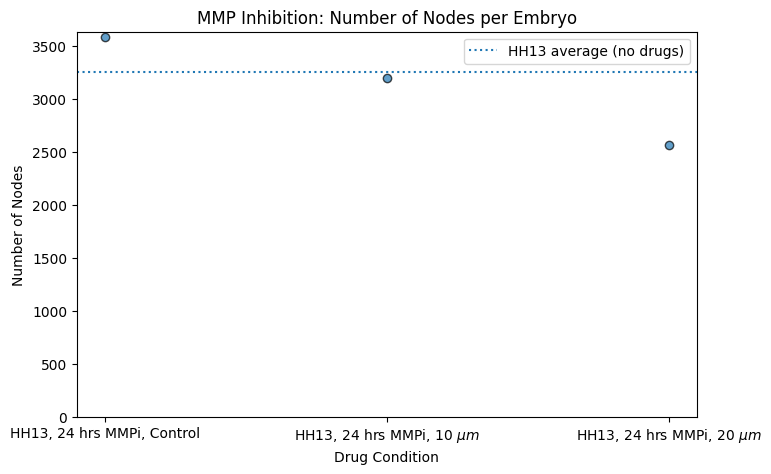

control nuclei    116.641767
10um nuclei        99.214045
20um nuclei         91.71958
Name: Mean Edge Length, dtype: object


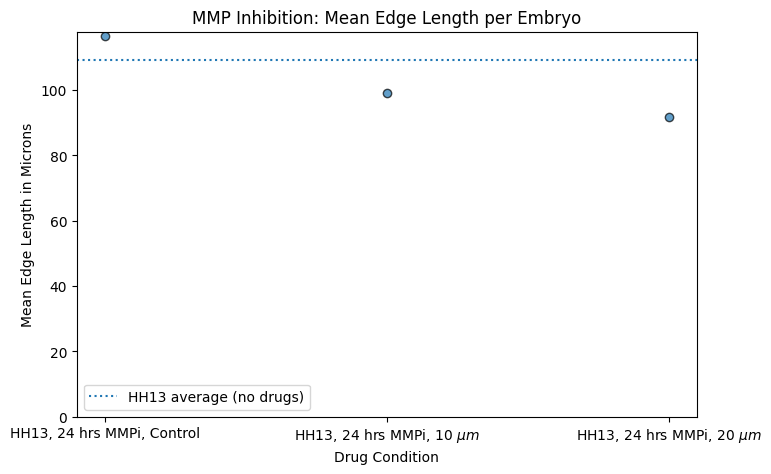

control nuclei    8.821684
10um nuclei       7.292384
20um nuclei       7.579671
Name: Mean Node Weight, dtype: object


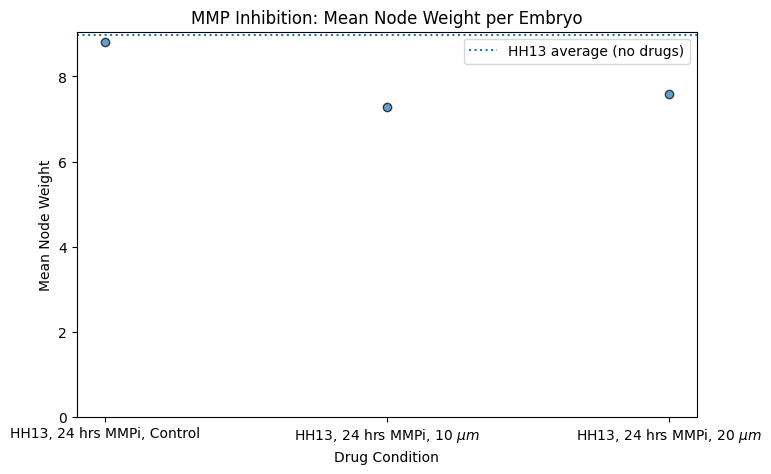

control nuclei    1.978436
10um nuclei       1.834418
20um nuclei       1.816302
Name: Average Degree of Non-Isolated Nodes, dtype: object


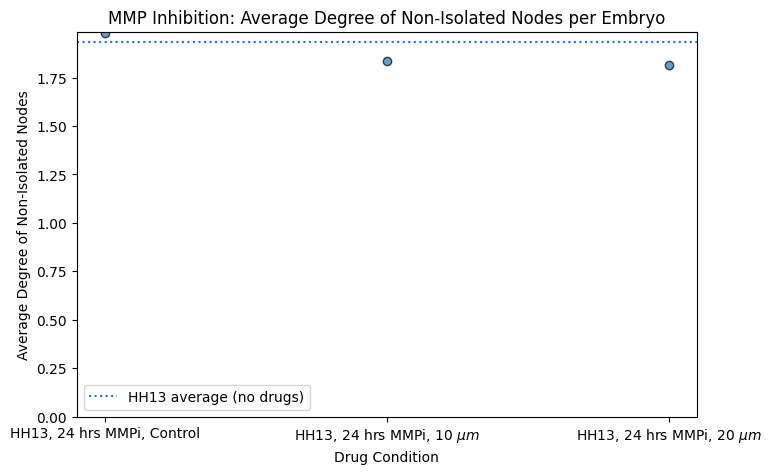

control nuclei    283
10um nuclei       160
20um nuclei       112
Name: Number of Basis Cycles, dtype: object


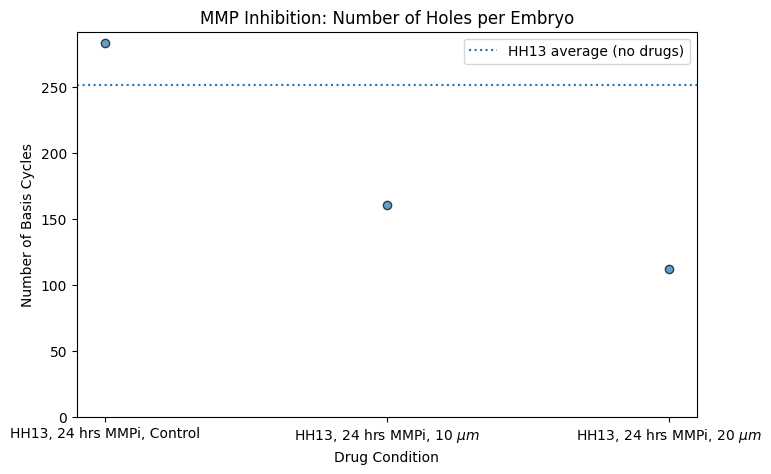

control nuclei    419
10um nuclei       532
20um nuclei       436
Name: Number of Components, dtype: object


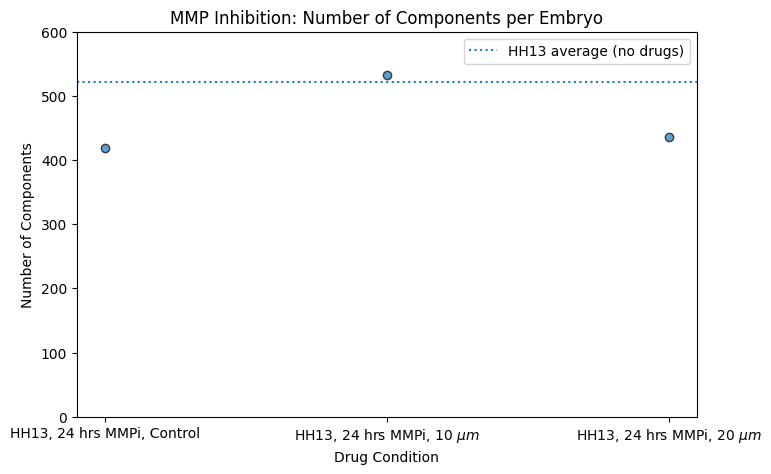

control nuclei    0.024933
10um nuclei       0.020269
20um nuclei       0.018692
Name: Average Clustering, dtype: object


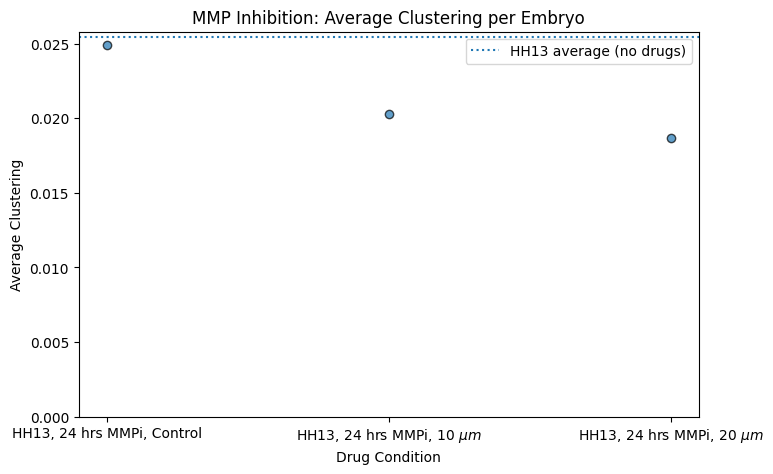

control nuclei    4137.216548
10um nuclei       3633.786209
20um nuclei        1822.31402
Name: Average Shortest Path, dtype: object


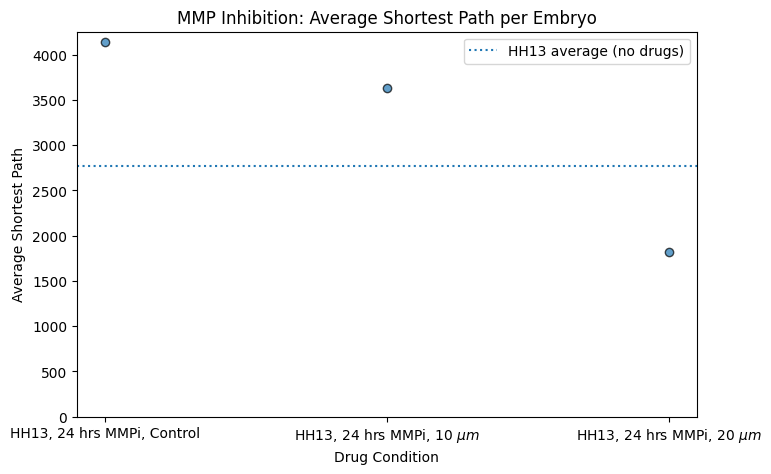

control nuclei    105
10um nuclei       123
20um nuclei       102
Name: Number of Isolated Nodes, dtype: object


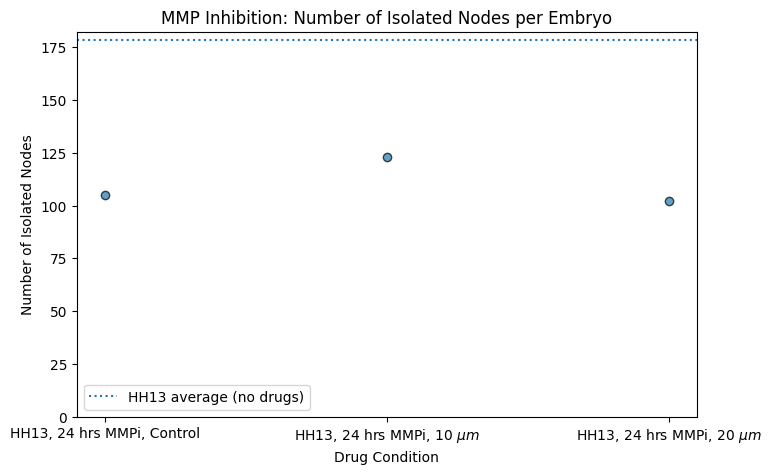

control nuclei    314
10um nuclei       409
20um nuclei       334
Name: Number of Components, Excluding Isolated Nodes, dtype: object


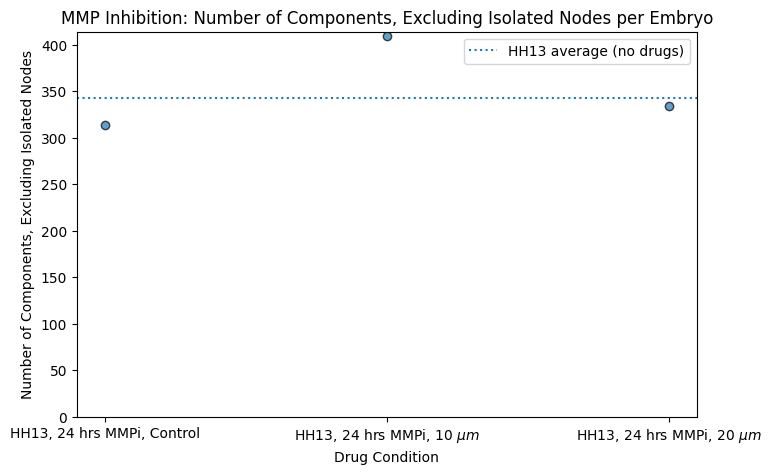

control nuclei    0.029305
10um nuclei       0.038474
20um nuclei        0.03972
Name: Proportion of Isolated Nodes, dtype: object


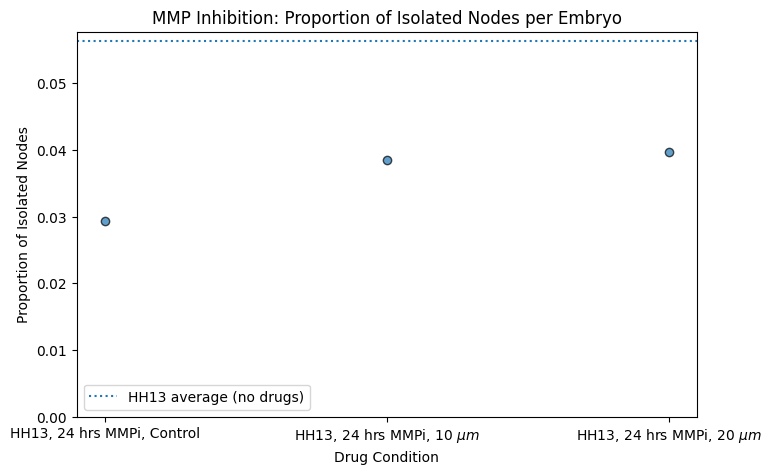

In [ ]:
#x_label = ["Control", "10um, 14 hr", "20um, 14 hr","30um, 14hr"]

x_label = "HH13, 24 hrs MMPi, " + np.array(["Control", "10 $\\mu m$", "20 $\\mu m$"])

#x_label = ["10um, 14 hr", "30um, 14 hr","50um, 14 hr"]
#print(df.loc["Number of Nodes"])
for i in properties:
    print(df.loc[i])
    plot_feature_drugs(i,df,x_label,"MMP Inhibition",hh13_means,"HH13")

In [12]:
def calc_degrees(adj,nodes):
    neighbours = adj.count()
    nodes["degree"] = neighbours
    return nodes

In [13]:
def calc_dists(adj,nodes):
    dists = adj.mean()
    nodes["distances"] = dists
    return nodes

In [14]:
#specify input image
stage=13
stage_id = stages.index(stage)
n=2

path = f"data/skeleton/all/"  
image = cv2.imread(f'{path}n{n}_hh{stage}_skeleton.jpg')
height = len(image)
width = len(image[0])
nodes = nodes_all_stages[stage_id][n-1]
adj = adj_all_stages[stage_id][n-1]

#append the degree data
nodes = calc_degrees(adj,nodes)


plt.figure(figsize=(8, 6))
# c='degree' maps the color to the feature, cmap is the color scheme
scatter = plt.scatter(nodes['x'], height-nodes['y'], c=nodes['degree'], cmap='viridis', s=10)
plt.colorbar(scatter, label='Number of Neighbors (Degree)')
plt.title(f'Connectivity of a HH{stage} Embryo')
plt.show()

TypeError: object of type 'NoneType' has no len()

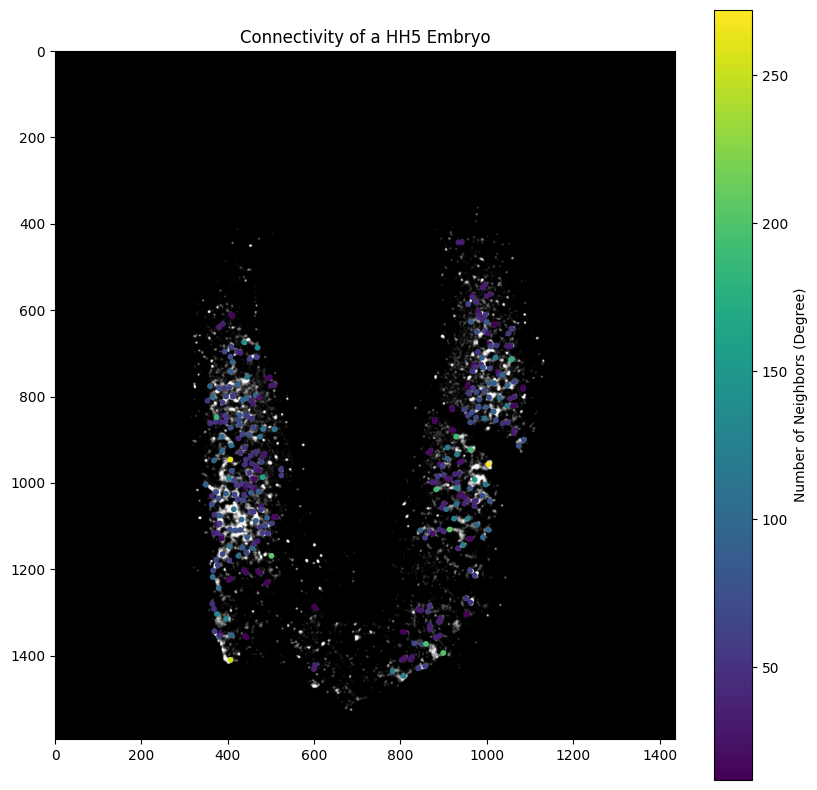

: 

In [ ]:
#specify input image
stage=5
stage_id = stages.index(stage)
n=2

path = f"data/skeleton/all/"  
image = cv2.imread(f'{path}n{n}_hh{stage}_plain_scaled.jpg')
height = len(image)
width = len(image[0])
nodes = nodes_all_stages[stage_id][n-1]
adj = adj_all_stages[stage_id][n-1]

#append the degree data
nodes = calc_dists(adj,nodes)



x_max,y_max = x_min+size,y_min+size

fig,ax=plt.subplots(figsize=(10,10))
# c='degree' maps the color to the feature, cmap is the color scheme
scatter = plt.scatter(nodes['x'], nodes['y'], c=nodes['distances'], cmap='viridis', s=10)
fig.colorbar(scatter, label='Number of Neighbors (Degree)')
ax.imshow(image, cmap=plt.cm.gray)
ax.set_title(f'Connectivity of a HH{stage} Embryo')

plt.show()

In [ ]:
stage = 6
n = 0

stage_id = stages.index(stage)


nodes = nodes_all_stages[stage_id][n]
adj = adj_all_stages[stage_id][n]


gen_pyvis_graph(nodes,adj,f"results/skeleton/hh{stages[stage_id]}_skeletonisation.html")

Local cdn resources have problems on chrome/safari when used in jupyter-notebook. 
edge between 95 and 95


<class 'pyvis.network.Network'> |N|=424 |E|=249

: 